# SQLite and Visuals

Import libraries

In [201]:
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3
import plotly.express as px
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import nbformat as nbf
import plotly.io as pio
import numpy as np


Import data

In [202]:
hpi_df = pd.read_csv('data/hpi_clean.csv')
med_inc_df = pd.read_csv('data/median_income_clean_w_change.csv')

In [203]:
conn = sqlite3.connect("hpi_v_medinc.db")
cursor = conn.cursor()

In [204]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS hpi (
    hpi_type TEXT NOT NULL,
    hpi_flavor TEXT NOT NULL,
    frequency TEXT PRIMARY KEY,
    level TEXT NOT NULL,
    place_name REAL NOT NULL,
    yr TEXT NOT NULL,
    index_nsa TEST NOT NULL          
);        
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS medinc (
    place_name TEXT NOT NULL,
    yr TEXT NOT NULL,
    median_income TEXT NOT NULL,
    change TEXT NOT NULL
);
""")

hpi_df.to_sql('hpi', conn, if_exists='replace', index=False)
med_inc_df.to_sql('medinc', conn, if_exists='replace', index=False)

print(pd.read_sql_query("SELECT * FROM hpi LIMIT 5", conn))
print(pd.read_sql_query("SELECT * FROM medinc LIMIT 5", conn))

      hpi_type     hpi_flavor  frequency  level place_name place_id    yr  \
0  traditional  purchase-only  quarterly  State     Alaska       AK  1991   
1  traditional  purchase-only  quarterly  State     Alaska       AK  1992   
2  traditional  purchase-only  quarterly  State     Alaska       AK  1993   
3  traditional  purchase-only  quarterly  State     Alaska       AK  1994   
4  traditional  purchase-only  quarterly  State     Alaska       AK  1995   

   period  index_nsa  index_sa  
0       1       0.00    100.00  
1       1       3.06    103.01  
2       1       5.16    105.02  
3       1      11.51    111.26  
4       1      14.80    114.52  
  place_name    yr median_income  change standard_error
0    Alabama  1991        24,350    0.00          1,068
1    Alabama  1992        25,810    6.00          1,058
2    Alabama  1993        25,080    3.00          1,088
3    Alabama  1994        27,200   11.70          1,559
4    Alabama  1995        25,990    6.74          1,266


Query to show the largest gap between HPI and Median Income. I am also creating a new datafram to use in a visualization

In [205]:
def query(query: str):
    return pd.read_sql(query, conn)

In [206]:
main_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC

""")

main_gap_df

,place_name,yr,hpi,income_index,gap
0,Montana,2024,592.48,229.92,362.56
1,Colorado,2024,582.25,238.10,344.15
2,Utah,2024,596.02,271.16,324.86
3,Oregon,2024,520.03,197.12,322.91
4,Idaho,2024,517.33,212.60,304.73
5,Washington,2024,471.85,187.02,284.83
6,Arizona,2024,455.32,175.54,279.78
7,Florida,2024,450.00,177.54,272.46
8,Wyoming,2024,415.35,170.84,244.51
9,North Carolina,2024,320.07,150.35,169.72


Query to show the ten states with the lowest gap between HPI and Median Income.


In [207]:
lowest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap ASC
Limit 10  
""")

lowest_gap_df   



,place_name,yr,hpi,income_index,gap
0,Mississippi,2024,196.37,187.37,9.00
1,West Virginia,2024,195.26,172.79,22.47
2,Illinois,2024,191.64,164.15,27.49
3,Connecticut,2024,174.83,135.44,39.39
4,Ohio,2024,219.22,170.29,48.93
5,Iowa,2024,251.32,199.40,51.92
6,Indiana,2024,240.39,183.17,57.22
7,Maryland,2024,254.20,196.89,57.31
8,Delaware,2024,231.62,163.46,68.16
9,North Dakota,2024,309.03,240.21,68.82


Query to show the 10 states with the largest gap between HPI and Median Income

In [208]:
largest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
Limit 10
""")

Query to show the most affordable states to live in in the years 1991 - 2024 showing a long term affordability not just current affordability. 

In [209]:
affordability_over_time_df = query("""
SELECT
    h.place_name,
    AVG(h.index_nsa / m.change) AS affordability_ratio
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
GROUP BY h.place_name
ORDER BY affordability_ratio ASC
LIMIT 10;
""")

Function to determine the gap between housing vs income gap for the years 1991 - 2024. This is for comparing two states.

In [210]:
def compare_states_with_gap(state1, state2):
    query_str = f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name IN ('{state1}', '{state2}')
    ORDER BY h.place_name, h.yr
    """
    
    return query(query_str)

In [211]:
def plot_compare_states_gap(state, state2):
    df = compare_states_with_gap(state, state2)


    plt.figure(figsize=(12, 6))


    for state in df['place_name'].unique():
        subset = df[df['place_name'] == state]
        plt.plot(
            subset['yr'],
            subset['gap'],
            linewidth=2.5,
            marker='o',
            markersize=5,
            label=state
    )

    
    plt.title('Housing vs Income Gap Over Time', fontsize=16, weight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Gap (HPI - Income Index)', fontsize=12)


    plt.grid(alpha=0.3)


    plt.legend(title='State', fontsize=10)


    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)


    plt.tight_layout()

    plt.show()

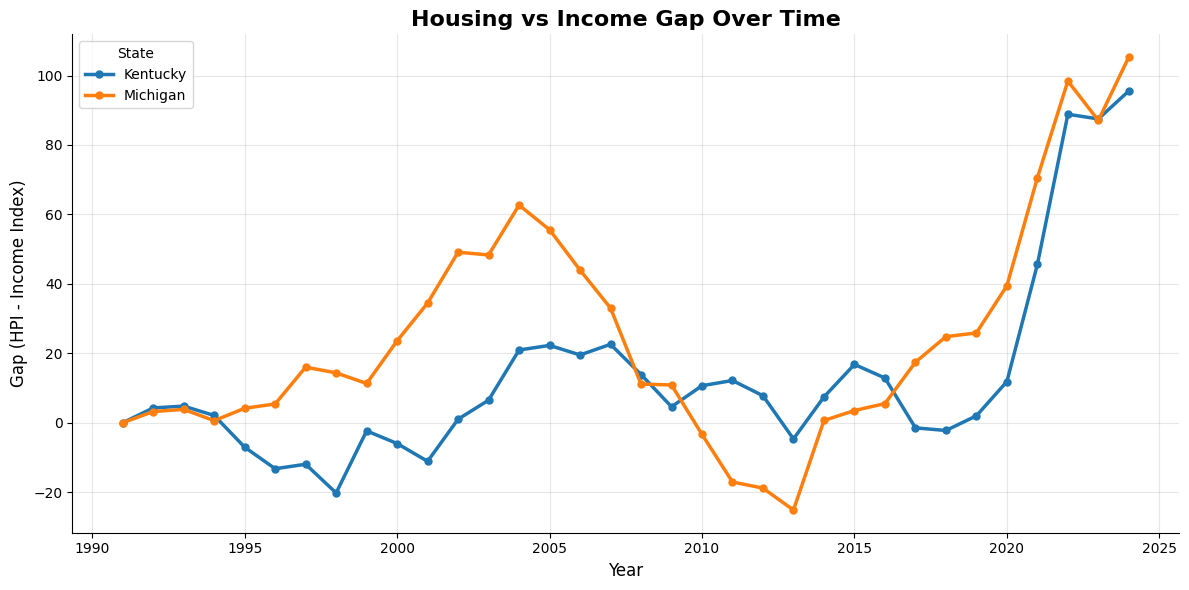

In [212]:
plot_compare_states_gap('Kentucky', 'Michigan')

In [220]:
def plot_state_hpi_vs_income(state):
    df = compare_states_with_gap(state, state) 

    subset = df[df['place_name'] == state]

    plt.figure(figsize=(12, 6))

    
    plt.plot(
        subset['yr'],
        subset['hpi'],
        linewidth=2.5,
        marker='o',
        label='HPI (Housing)'
    )

    
    plt.plot(
        subset['yr'],
        subset['income_index'],
        linewidth=2.5,
        linestyle='-',
        marker='o',
        label='Income'
    )

    
    plt.axhline(100, linestyle='-', linewidth=1)

    
    plt.title(f'{state}: HPI Increase vs Income Growth', fontsize=16, weight='bold')
    plt.xlabel('Year')
    plt.ylabel('% Change')

    
    plt.grid(alpha=0.3)
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

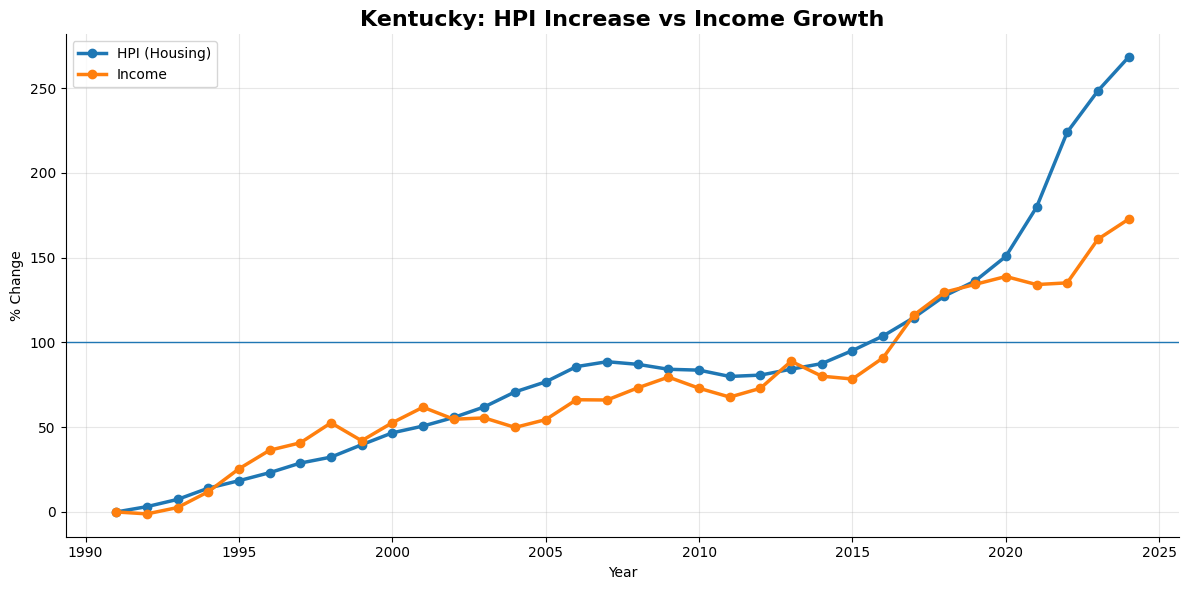

In [225]:
plot_state_hpi_vs_income('Kentucky')

In [215]:
usa_med_inc_hpi_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
""")

In [216]:
state_map = {
    'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR',
    'California': 'CA','Colorado': 'CO','Connecticut': 'CT','Delaware': 'DE',
    'Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID',
    'Illinois': 'IL','Indiana': 'IN','Iowa': 'IA','Kansas': 'KS',
    'Kentucky': 'KY','Louisiana': 'LA','Maine': 'ME','Maryland': 'MD',
    'Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN','Mississippi': 'MS',
    'Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV',
    'New Hampshire': 'NH','New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY',
    'North Carolina': 'NC','North Dakota': 'ND','Ohio': 'OH','Oklahoma': 'OK',
    'Oregon': 'OR','Pennsylvania': 'PA','Rhode Island': 'RI','South Carolina': 'SC',
    'South Dakota': 'SD','Tennessee': 'TN','Texas': 'TX','Utah': 'UT',
    'Vermont': 'VT','Virginia': 'VA','Washington': 'WA','West Virginia': 'WV',
    'Wisconsin': 'WI','Wyoming': 'WY'
}

In [217]:
usa_med_inc_hpi_gap_df['place_id'] = usa_med_inc_hpi_gap_df['place_name'].map(state_map)

In [218]:
usa_med_inc_hpi_gap_df[['place_name','place_id']].head()

,place_name,place_id
0,Montana,MT
1,Colorado,CO
2,Utah,UT
3,Oregon,OR
4,Idaho,ID


In [219]:
fig = px.choropleth(
    usa_med_inc_hpi_gap_df,
    locations='place_id',
    locationmode='USA-states',
    scope='usa',
    color='gap',
    color_continuous_scale='Jet',   
    range_color=[0, 400],
    hover_name='place_name',              
    hover_data={'gap': ':.2f'},
    title='Housing vs Income Gap by State (2024)'

)
fig.update_layout(height=500, width=800)
fig.update_layout(title_text='Housing vs Income Gap by State (2024)', title_x=0.5)
fig.show()

In [222]:
bar_df = query("""
SELECT
    h.place_name,
    h.index_nsa AS hpi,
    m.change AS income_index
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
""")

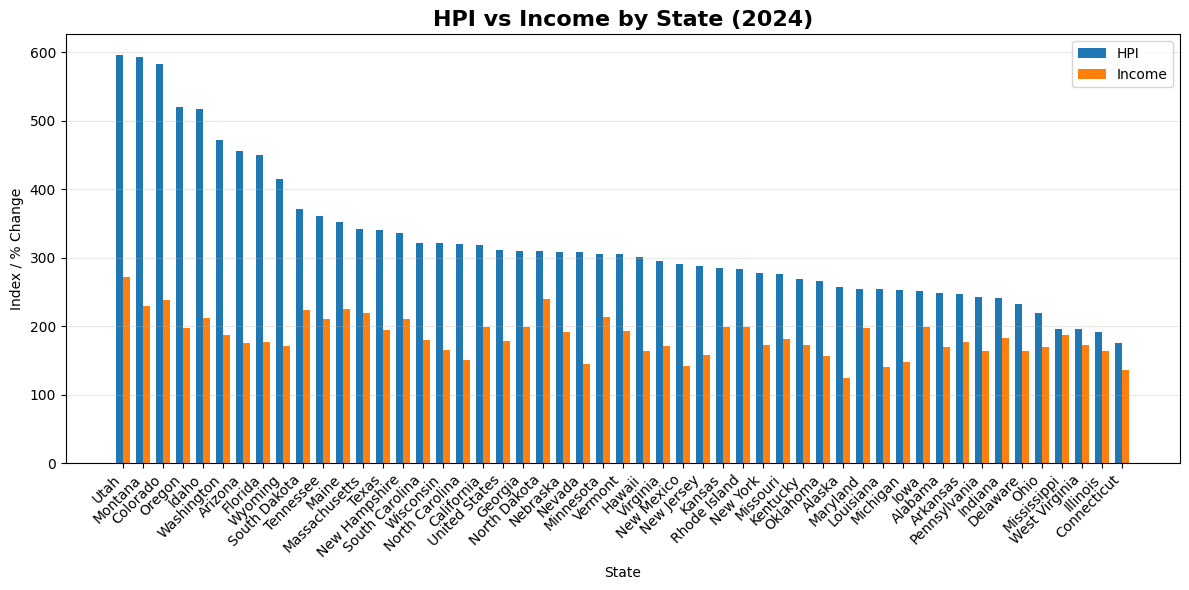

In [224]:

bar_df = bar_df.sort_values('hpi', ascending=False)

x = np.arange(len(bar_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, bar_df['hpi'], width, label='HPI')
plt.bar(x + width/2, bar_df['income_index'], width, label='Income')

# Labels
plt.xticks(x, bar_df['place_name'], rotation=45, ha='right')
plt.title('HPI vs Income by State (2024)', fontsize=16, weight='bold')
plt.ylabel('Index / % Change')
plt.xlabel('State')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()